In [53]:
# we need it in all codes
import numpy as np 
import math
import matplotlib.pyplot as plt
from PIL import Image
# see functions here
# https://numpy.org/doc/stable/reference/generated/numpy.exp.html
# https://numpy.org/doc/stable/reference/routines.array-manipulation.html
#

# basic vector and matrix operations
# general principle: we do not have to write functions for everything
# moreover, built-in vectorized operations are rather fast


# COMPUTE VECTOR NORMS

In [54]:
s = np.array([3,4])
# Compute the norm of s. This measures the "size" of the vector
np.linalg.norm(s)

np.float64(5.0)

In [55]:
# Compute the angle between [1/2, sqrt(3)] and [1,1].
# remember the classical formula for scalar products
v1 = np.array([1/2, math.sqrt(3)])
v2 = np.array([1, 1])
#Recall:  u \cdot v = cos (theta) |u| |v|
cos_angle = v1@v2 / (np.linalg.norm(v1)*np.linalg.norm(v2)) 
angle = math.acos(cos_angle)
print(f"the angle between v1 and v2 is: {angle} rad")
# pi rad = 180 degrees, e.g. angle rad  = angle*180/pi
print(f"This angle in degrees is {angle*180/math.pi} degrees")
# Be careful: this is given in radians. Let us give it in degrees.

the angle between v1 and v2 is: 0.504363261894635 rad
This angle in degrees is 28.897886248014 degrees


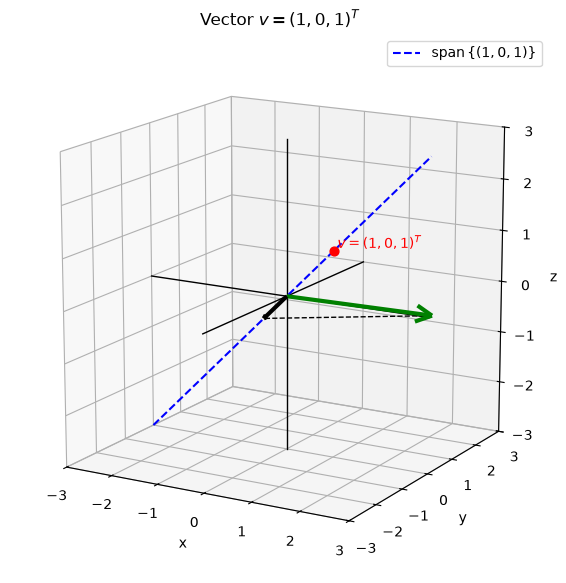

In [56]:
#PROJECTION FORMULA VISUALIZED:
# Create a 3D figure #(8 wide x 7 high image)
fig = plt.figure(figsize=(8, 7))
#Adding a coordinate system to our figure, and tells matplotlib ax should be 3d.
# fig.add_subplot(number_of_rows, number_of_columns, position)
#if we wanted 2 figures one below the other, we do ax1 2 1 1, then  ax2 2 1 2
ax = fig.add_subplot(1, 1, 1, projection="3d")
#limit of our x,y,z axis. 
limit = 3

# Draw the Cartesian coordinate axes
#In a 3D plot, ax.plot receives three lists: x limits, y limits z limits 
ax.plot([-limit, limit], [0, 0], [0, 0],
        color="black", linewidth=1)  # x-axis

ax.plot([0, 0], [-limit, limit], [0, 0],
        color="black", linewidth=1)  # y-axis

ax.plot([0, 0], [0, 0], [-limit, limit],
        color="black", linewidth=1)  # z-axis

# The vector
v = np.array([1, 0, 1])
v2 = np.array([0.5, 5, -1.5]) #vector outside of span
projec_vM = np.array([ [1/2, 0, 1/2],
                        [0, 0 , 0],
                        [1/2, 0, 1/2]]) #Projection matrix
v2_onto_v = projec_vM @ v2 #Projecting v2 onto line

# Draw the vector starting from (0,0,0)
#qax.quiver(x, y, z, u, v, w) x,y,z starting point and u,v,w end point

ax.quiver(
    0, 0, 0,          # starting point
    v2[0], v2[1], v2[2], # vector components
    color="green",
    linewidth=3,
    arrow_length_ratio=0.12
)

ax.quiver(
    0, 0, 0,          # starting point
    v2_onto_v[0], v2_onto_v[1], v2_onto_v[2], # vector components
    color="black",
    linewidth=3,
    arrow_length_ratio=0.12
)

ax.quiver(
    v2_onto_v[0], v2_onto_v[1], v2_onto_v[2],          # starting point
    v2[0]-v2_onto_v[0], v2[1]-v2_onto_v[1], v2[2]-v2_onto_v[2], # vector components
    linestyle="--",
    color="black",
    linewidth=1,
    arrow_length_ratio=0
)

# Mark and label its endpoint.
#scatter draws the dot at the point v, s controls the marker size
ax.scatter(v[0], v[1], v[2], color="red", s=40)
#we write a label very close to this point
ax.text(v[0] + 0.05, v[1] + 0.05, v[2] + 0.05,
        r"$v=(1,0,1)^T$", color="red")

# Axis labels and limits
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_zlim(-limit, limit)

# Give all axes the same visual scale
ax.set_box_aspect((1, 1, 1))

ax.set_title(r"Vector $v=(1,0,1)^T$")

#This chooses the view position of the "camera"
ax.view_init(elev=15, azim=-60) #25 deg. above horizontal plane, -55 deg wrt z axis

#Drawing also the span of (1,0,1)
t = np.linspace(-limit, limit, 100)
ax.plot(
    t,           # x = t
    np.zeros_like(t),  # y = 0
    t,           # z = t
    linestyle="--",
    color="blue",
    label=r"$\operatorname{span}\{(1,0,1)\}$"
)

ax.legend()
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

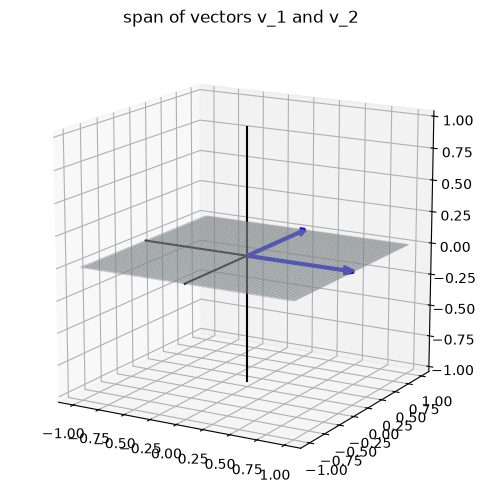

In [57]:
#Let's see the span of two vectors v_1, v_2
fig = plt.figure(figsize= (8,6) )
#create axis
ax = fig.add_subplot (1,1,1, projection="3d")
limit = 1
#plotting
ax.plot([-limit, limit], [0, 0], [0,0], color = 'black')
ax.plot ([0, 0], [-limit, limit], [0, 0], color='black')
ax.plot( [0, 0], [0, 0], [-limit, limit], color = 'black')
ax.set_box_aspect((1,1,1))

#Spanning vectors
v_1 = np.array([1,0,0])
v_2 = np.array([0,1,0])


#Generate a mesh: using np.meshgrid:
s = np.linspace(-limit, limit,100)
t = np.linspace(-limit, limit,100)
S,T = np.meshgrid(s, t)
#The span of v_1,v_2 is sv_1 +t v_2!
#In coordinate form:
X = S * v_1[0] + T * v_2[0] 
Y = S * v_1[1] + T * v_2[1] 
Z = S * v_1[2] + T * v_2[2]  

ax.view_init(elev=15, azim=-60)
ax.plot_surface(X, Y, Z, color = 'lightblue', alpha = 0.25, edgecolor = 'gray') #smaller alpha makes surface more transparent

#Plotting spanning vectors:
ax.quiver(0, 0 ,0,
          v_1[0], v_1[1], v_1[2], color='blue', linewidth=3, arrow_length_ratio = 0.1)
ax.quiver(0, 0 ,0,
          v_2[0], v_2[1], v_2[2], color='blue', linewidth=3, arrow_length_ratio = 0.1)
ax.set_title("span of vectors v_1 and v_2")
plt.show

In [58]:
#Sine and cosine of vectors. Takes the sine and cosine componentwise
w=np.linspace(1,100,100)
w_sin = np.sin(w)
#print(w_sin)
w_cos = np.cos(w)
#print(w_cos)
#create a matrix using these vectors
w_all = np.array([w_sin, 
                  w_cos])

print("we created a matrix such that its first row is the sine of (1,...,100) and the second row the cosine of said vector")
print(f"Its shape is: {w_all.shape}")

#Our goal is to create a vector like this:
# [sin a_1, cos a_1, sin a_2, cos a_2, sin a_3, cos a_3, . . .]
#Since reshape works row wise, it's better if we transpose this matrix so first column has sines and second column has cosines





we created a matrix such that its first row is the sine of (1,...,100) and the second row the cosine of said vector
Its shape is: (2, 100)


# ORTHOGONAL DECOMPOSITIONS

In [59]:
# Compute the orthogonal decomposition of [1, 1, 1] 
# with respect to the vector [2, 3, 5].
# Apply the formula in the lecture notes: Recall for any vector v = projv + projv_perp
 #Proj_v2 (v1) = v1 \cdot v2 / |v2|^2 * v2
#Then its perpendicular component w.r.t. [2 3 5] is 
# Verify that they are really orthogonal.
v1 = np.array([1, 1, 1])
v2 = np.array([2, 3, 5])
direction_of_v2 =  (v1@v2) /(v2@v2) * v2
print("The orthogonal projection of [1 1 1] onto v2 is: (parallel component)")
print(direction_of_v2)
print("its perpendicular component is v - Proj_v2 (v):")
ortog_to_v2 = v1 - direction_of_v2
print(ortog_to_v2)
print("let's check they are orthogonal by computing their dot product, this should be 0 (or close to zero due to rounding errors)")
print(direction_of_v2 @ ortog_to_v2)


The orthogonal projection of [1 1 1] onto v2 is: (parallel component)
[0.52631579 0.78947368 1.31578947]
its perpendicular component is v - Proj_v2 (v):
[ 0.47368421  0.21052632 -0.31578947]
let's check they are orthogonal by computing their dot product, this should be 0 (or close to zero due to rounding errors)
2.220446049250313e-16


In [60]:
# we have three compounds, in which the ratio of the components are:
# [0.75, 0.1, 0.1, 0.05]   [0.8, 0.1, 0.05, 0.05] and [0.7, 0.2, 0.1, 0]

# another compound has the component-ratio v= [0.75, 0.15, 0.1, 0]

# Which one is more similar to v? 
    #1. How can we measure similarity? We will check the norm of the perpendicular component of our vectors w.r.t v
    #2.  Define the distance as the orthogonal component in the decomposition
    #3. The vector with the smallest distance will be declared the most similar

# with respect to the given compounds.
c1 = np.array([0.75, 0.1, 0.1, 0.05])   
c2 = np.array([0.8, 0.1, 0.05, 0.05])
c3 = np.array([0.7, 0.2, 0.1, 0])
v = np.array([0.75, 0.15, 0.1, 0])
#Projections onto v:
direction_of_c1 = v * (v@c1) /(c1@c1)
direction_of_c2 = v * (v@c2) /(c2@c2)
direction_of_c3 = v * (v@c3) /(c3@c3)
#Perpendicular components w.r.t v:

ortog_to_c1 = v - direction_of_c1
ortog_to_c2 = v - direction_of_c2
ortog_to_c3 = v - direction_of_c3

distances = np.array([np.linalg.norm(ortog_to_c1), np.linalg.norm(ortog_to_c2), np.linalg.norm(ortog_to_c3)])
print(f"The shortest distance is {np.min(distances)} and it corresponds to  the {np.argmin(distances)+1}st compound")

The shortest distance is 0.003296420645414951 and it corresponds to  the 1st compound


# COMPUTING MATRIX RANKS

In [61]:
from numpy.linalg import matrix_rank
# compute the rank of the identity matrix of size 5 x 5 
print(matrix_rank(np.eye(5))) 
# compute the rank of the ones-matrix of size 5 x 5 
print(matrix_rank(np.ones((5,5))))
# Change one element of the identity matrix of size 4 x 4
# to obtain a matrix of rank 3.
I =np.eye(4); I[-1,-1] = 0.
matrix_rank(I)

5
1


np.int64(3)

# CONSTRUCTING A STOCHASTIC MATRIX AND A PERMUTATION MATRIX

In [62]:
# Create a stochastic matrix starting from a random matrix 
# by dividing each row accordingly.
R = np.random.randint(10, size=(8, 18))
R_new = np.zeros((8,18))
print(R)
# Take sum of the rows easily obtained using dot product with vector of ones
R_rowsum = R @ np.ones([18,])
print(R_rowsum)
# Divide each row with the row-sum
for j in range(8):
    R_new[j,:] = R[j,:]/R_rowsum[j]
# Verify that this is indeed stochastic.
# What is a clever method for this?
print(R_new @ np.ones([18,]))

[[6 0 2 8 8 3 1 0 8 0 5 4 6 9 7 3 8 1]
 [2 2 6 9 1 3 6 6 6 7 2 0 2 3 3 2 5 9]
 [9 7 3 7 0 0 0 0 2 9 2 0 6 6 4 9 1 8]
 [4 0 6 7 5 9 0 6 4 3 6 1 2 5 7 2 6 1]
 [8 9 6 2 4 3 5 6 7 9 5 3 6 6 3 1 8 8]
 [2 8 0 3 0 2 5 3 7 3 1 7 3 0 7 9 6 9]
 [1 4 0 5 9 0 6 6 9 1 2 2 0 5 3 4 3 5]
 [9 2 6 3 2 7 5 1 3 9 3 1 5 2 3 9 7 1]]
[79. 74. 73. 74. 99. 75. 65. 78.]
[1. 1. 1. 1. 1. 1. 1. 1.]


In [63]:
# Create the permutation matrix, which corresponds to the permutation
# [2 3 5 1 4]   of the numbers [1 2 3 4 5]
index_perm = np.array([2,3,5,1,4])
P = np.eye(5,dtype=int)[:,index_perm-1] #From the columns, we will take in order: index_perm[0]-1,...
print('Permutation matrix corresponding to [2 3 5 1 4]   of the numbers [1 2 3 4 5]')
print(P)
# create the permutation matrix, which corresponds to the permutation
# [16 2 10 15 8 1 3 12 18 4 7 17 6 11 9 5 13 14]
v = np.array([16, 2, 10, 15, 8, 1, 3, 12, 18, 4, 7, 17, 6, 11, 9, 5, 13, 14])

print("Permutation matrix corresponding to [16 2 10 15 8 1 3 12 18 4 7 17 6 11 9 5 13 14] permutation")

# Now, verify that each row of this matrix has only one nonzero element

# Verify this nonzero element is actually 1.

# What is the norm of this matrix? 


Permutation matrix corresponding to [2 3 5 1 4]   of the numbers [1 2 3 4 5]
[[0 0 0 1 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [0 0 1 0 0]]
Permutation matrix corresponding to [16 2 10 15 8 1 3 12 18 4 7 17 6 11 9 5 13 14] permutation
